<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/homework/pandas_viz_practice_80tasks_29_05_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas + Matplotlib: практикум на 80 завдань

**Рівень:** середній (pandas) + початковий (matplotlib)

---

Цей зошит містить **80 завдань**:
- **50 завдань pandas** — поглиблюємо те, що вивчили, додаємо `loc`/`iloc`, `pivot_table`, складніший `groupby`
- **30 завдань візуалізації** — pandas `.plot()` + основи matplotlib з кольорами, стилями та легендами

## Дані
Працюємо з даними стрімінгового сервісу. Два файли:

**`streaming_subscribers.csv`** (600 рядків) — підписники сервісу:

| Стовпець | Опис |
|---|---|
| `subscriber_id` | Унікальний номер підписника |
| `age` | Вік |
| `gender` | Стать (Ч / Ж) |
| `country` | Країна (Україна, Польща, Німеччина, Чехія, Литва, Іспанія) |
| `plan` | Тариф (Basic / Standard / Premium / Family) |
| `monthly_fee` | Місячна плата (грн) |
| `join_date` | Дата реєстрації |
| `is_active` | Активний абонемент (Так / Ні) |

**`streaming_sessions.csv`** (5000 рядків) — сеанси перегляду:

| Стовпець | Опис |
|---|---|
| `session_id` | Унікальний номер сеансу |
| `subscriber_id` | ID підписника (зв'язок з першою таблицею) |
| `date` | Дата перегляду |
| `genre` | Жанр |
| `device` | Пристрій (Smart TV / Laptop / Mobile / Tablet) |
| `duration_min` | Тривалість перегляду в хвилинах |
| `rating` | Оцінка користувача (1-5) |

## Як працювати
- У кожній комірці є коментар з номером завдання — пишіть код під ним
- Запускайте кожну комірку (Shift + Enter), щоб бачити результат
- Якщо забули синтаксис — користуйтесь шпаргалкою з pandas та новою шпаргалкою matplotlib
- Не бійтесь експериментувати!

---

## Підготовка

Запустіть цю комірку — вона завантажує бібліотеки та дані. Усі завдання використовують змінні `subs` (підписники) та `sess` (сеанси).

In [173]:
import pandas as pd
import matplotlib.pyplot as plt

subs = pd.read_csv("streaming_subscribers.csv")
sess = pd.read_csv("streaming_sessions.csv")

# Перетворюємо дати на справжній формат
subs["join_date"] = pd.to_datetime(subs["join_date"])
sess["date"] = pd.to_datetime(sess["date"])

print("Підписники:", subs.shape)
print("Сеанси:", sess.shape)
subs.head()

Підписники: (600, 8)
Сеанси: (5000, 7)


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так


---

# Частина 1. Pandas (50 завдань)

Розділи:
1. Розминка — повторення (1-8)
2. `loc` та `iloc` — вибірка за позиціями та мітками (9-18)
3. Складніший groupby (19-28)
4. `pivot_table` — зведені таблиці (29-36)
5. Робота з датами + обчислення (37-44)
6. Комбіновані завдання (45-50)

## Розділ 1.1. Розминка (завдання 1-8)

Швидке повторення того, що вже знаємо.

**Завдання 1.** Виведіть перші 10 рядків таблиці `sess`.

In [174]:
# Завдання 1:
sess.head(10)

,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Анімація,Mobile,72,1
1,50017,1429,2024-06-25,Романтика,Mobile,53,5
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5
3,54446,1520,2024-07-01,Серіал,Laptop,66,3
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5
5,51938,1078,2024-08-27,Документальний,Mobile,60,4
6,52050,1343,2024-02-26,Бойовик,Tablet,86,3
7,54963,1444,2024-08-04,Серіал,Smart TV,56,4
8,50908,1521,2024-04-02,Драма,Smart TV,68,4
9,51976,1555,2024-04-11,Драма,Mobile,84,5


**Завдання 2.** Скільки всього підписників у даних? А сеансів?

> 💡 Атрибут `shape[0]` або функція `len()`.

In [175]:
# Завдання 2:
print("Кількість підписників:", subs.shape[0])
print("Кількість сеансів:", sess.shape[0])

Кількість підписників: 600
Кількість сеансів: 5000


**Завдання 3.** Виведіть кількість підписників по кожній країні. Відсортуйте за спаданням.

> 💡 `value_counts()` вже сортує за спаданням за замовчуванням.

In [176]:
# Завдання 3:
print('Кількість підписників по кожній країні:')
print(subs['country'].value_counts())

Кількість підписників по кожній країні:
country
Україна      256
Німеччина    101
Польща        77
Чехія         68
Іспанія       62
Литва         36
Name: count, dtype: int64


**Завдання 4.** Знайдіть середній вік підписників.

In [177]:
# Завдання 4:
print("Середній вік підписників:", round(subs['age'].mean(), 0))

Середній вік підписників: 43.0


**Завдання 5.** Знайдіть мінімальну та максимальну тривалість сеансу.

In [178]:
# Завдання 5:
print("Максимальна тривалість сеансу:", sess['duration_min'].max(), "хвилин")
print("мінімальна тривалість сеансу:", sess['duration_min'].min(), "хвилин")

Максимальна тривалість сеансу: 171 хвилин
мінімальна тривалість сеансу: 5 хвилин


**Завдання 6.** Скільки підписників активні (`is_active == "Так"`)?

In [179]:
# Завдання 6:
print("Кількість активних підписників:", (subs['is_active'] == "Так").sum())

Кількість активних підписників: 447


**Завдання 7.** Виведіть тільки сеанси з жанром `Драма` та оцінкою 5.

> 💡 Дві умови через `&`, кожна в дужках.

In [180]:
# Завдання 7:
print("Сеанси з жанром Драма та оцінкою 5:\n")
display(sess[(sess['genre'] == 'Драма') & (sess['rating'] == 5)])

Сеанси з жанром Драма та оцінкою 5:



,session_id,subscriber_id,date,genre,device,duration_min,rating
9,51976,1555,2024-04-11,Драма,Mobile,84,5
68,51372,1447,2024-06-19,Драма,Tablet,93,5
74,53138,1074,2024-01-05,Драма,Laptop,48,5
94,52201,1124,2024-06-17,Драма,Laptop,34,5
117,53459,1454,2024-05-04,Драма,Mobile,77,5
...,...,...,...,...,...,...,...
4852,52566,1345,2024-03-28,Драма,Laptop,43,5
4855,51811,1579,2024-04-04,Драма,Smart TV,99,5
4902,53655,1551,2024-06-30,Драма,Laptop,48,5
4939,50494,1468,2024-01-30,Драма,Smart TV,36,5


**Завдання 8.** Створіть у таблиці `subs` новий стовпець `annual_fee` = `monthly_fee` × 12.

In [181]:
# Завдання 8:
subs['annual_fee'] = subs['monthly_fee'] * 12
display(subs.head())

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні,3948
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так,2628
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так,1788
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так,1788
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так,2628


## Розділ 1.2. loc та iloc (завдання 9-18)

`iloc` працює за **числовими позиціями** (як індекси у списку):
- `df.iloc[0]` — перший рядок
- `df.iloc[0:5]` — рядки 0-4
- `df.iloc[0, 2]` — рядок 0, стовпець 2
- `df.iloc[:, 1:3]` — усі рядки, стовпці 1-2

`loc` працює за **мітками** (назвами):
- `df.loc[0]` — рядок з міткою 0
- `df.loc[df["age"] > 30, "country"]` — фільтр + конкретний стовпець
- `df.loc[df["plan"] == "Premium", ["age", "country"]]` — фільтр + кілька стовпців

**Завдання 9.** Виведіть перший рядок таблиці `subs` за допомогою `iloc`.

> 💡 `subs.iloc[0]`.

In [182]:
# Завдання 9:

# display(subs.iloc[0])
display(subs.iloc[[0]])

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні,3948


**Завдання 10.** Виведіть рядки з 10 по 15 (включно) таблиці `subs` за допомогою `iloc`.

> 💡 `iloc[10:16]` (правий кінець не включається).

In [183]:
# Завдання 10:
display(subs.iloc[10:16])

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
10,1011,16,Ч,Іспанія,Family,449,2023-09-17,Так,5388
11,1012,56,Ч,Україна,Standard,219,2024-12-08,Так,2628
12,1013,25,Ч,Іспанія,Standard,219,2023-01-01,Так,2628
13,1014,17,Ч,Україна,Standard,219,2023-07-21,Так,2628
14,1015,55,Ж,Україна,Standard,219,2022-02-14,Ні,2628
15,1016,20,Ч,Польща,Premium,329,2022-06-09,Ні,3948


**Завдання 11.** Виведіть значення з 5-го рядка, 3-го стовпця таблиці `subs`.

> 💡 `iloc[5, 3]`. Нумерація з нуля!

In [184]:
# Завдання 11:
subs.iloc[4, 2]

'Ж'

**Завдання 12.** Виведіть перші 3 стовпці таблиці `sess` (усі рядки) за допомогою `iloc`.

> 💡 `iloc[:, :3]`.

In [185]:
# Завдання 12:
display(sess.iloc[:, :3])

,session_id,subscriber_id,date
0,51573,1166,2024-04-11
1,50017,1429,2024-06-25
2,50861,1404,2024-07-05
3,54446,1520,2024-07-01
4,51561,1052,2024-06-13
...,...,...,...
4995,52398,1356,2024-08-19
4996,51013,1208,2024-03-17
4997,54579,1174,2024-05-25
4998,52743,1431,2024-07-23


**Завдання 13.** Виведіть рядки 100-104, тільки стовпці `age` та `country`. Використайте `iloc`.

> 💡 `iloc[100:105, [1, 3]]` — індекси стовпців: age=1, country=3.

In [186]:
# Завдання 13:
display(subs.iloc[100:105, [1, 3]])

,age,country
100,63,Польща
101,21,Німеччина
102,62,Польща
103,48,Україна
104,54,Україна


**Завдання 14.** За допомогою `loc` виведіть тільки тих підписників, у яких вік більше 50. Поверніть тільки стовпці `country` та `plan`.

> 💡 `subs.loc[subs["age"] > 50, ["country", "plan"]]`.

In [187]:
# Завдання 14:
display(subs.loc[subs['age'] > 50, ['country', 'plan']])

,country,plan
2,Україна,Basic
11,Україна,Standard
14,Україна,Standard
16,Німеччина,Standard
18,Польща,Standard
...,...,...
593,Іспанія,Basic
594,Україна,Basic
595,Україна,Premium
598,Чехія,Standard


**Завдання 15.** За допомогою `loc` виведіть стовпець `monthly_fee` тільки для активних підписників (`is_active == "Так"`).

In [188]:
# Завдання 15:
display(subs.loc[subs['is_active'] == "Так", ['monthly_fee']])

,monthly_fee
1,219
2,149
3,149
4,219
5,219
...,...
594,149
595,329
596,449
597,449


**Завдання 16.** Знайдіть середній вік підписників з тарифом `Premium`, використовуючи `loc`.

> 💡 `subs.loc[subs["plan"]=="Premium", "age"].mean()`.

In [189]:
# Завдання 16:
avg_premium = round(subs.loc[subs['plan']=='Premium', 'age'].mean(), 0)
print(f"Середній вік підписників з тарифом Premium: {avg_premium} роки")

Середній вік підписників з тарифом Premium: 42.0 роки


**Завдання 17.** Використовуючи `loc`, ЗМІНІТЬ значення `is_active` на `"Так"` для підписника з `subscriber_id == 1001`.

> 💡 `subs.loc[subs["subscriber_id"]==1001, "is_active"] = "Так"`. Потім перевірте результат.

In [190]:
# Завдання 17:
subs.loc[subs['subscriber_id'] == 1001, 'is_active'] = "Так"
display(subs.loc[subs['subscriber_id'] == 1001])

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Так,3948


**Завдання 18.** Виведіть останні 5 рядків таблиці `subs` за допомогою `iloc` (без `tail`).

> 💡 Від'ємні індекси: `iloc[-5:]`.

In [191]:
# Завдання 18:
display(subs.iloc[-5:])

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
595,1596,53,Ж,Україна,Premium,329,2022-04-15,Так,3948
596,1597,30,Ч,Україна,Family,449,2024-03-26,Так,5388
597,1598,38,Ч,Німеччина,Family,449,2024-06-12,Так,5388
598,1599,64,Ж,Чехія,Standard,219,2024-05-03,Ні,2628
599,1600,68,Ч,Польща,Standard,219,2022-07-28,Так,2628


## Розділ 1.3. Складніший groupby (завдання 19-28)

Нові можливості:
- `.agg(["sum", "mean", "count"])` — кілька агрегатів одразу
- `.agg({"col1": "mean", "col2": "sum"})` — різні агрегати на різні стовпці
- `.transform("mean")` — повертає те саме число для кожного рядка групи (зручно для нових стовпців)
- `groupby(["col1", "col2"])` — групування за кількома стовпцями
- `.size()` — кількість рядків у кожній групі

**Завдання 19.** Для кожної країни виведіть кількість підписників та середній вік за один виклик `agg`.

> 💡 `subs.groupby("country").agg({"subscriber_id": "count", "age": "mean"})`.

In [192]:
# Завдання 19:
display(subs.groupby('country').agg({'subscriber_id':'count', 'age':'mean'}).round({'age': 0}))

,subscriber_id,age
country,,
Іспанія,62,43.0
Литва,36,40.0
Німеччина,101,45.0
Польща,77,43.0
Україна,256,44.0
Чехія,68,41.0


**Завдання 20.** Для кожного тарифу (`plan`) виведіть мінімальний, середній і максимальний вік підписників.

> 💡 `agg(["min", "mean", "max"])` на стовпці `age`.

In [193]:
# Завдання 20:

# display(subs.groupby('plan').agg({'age':['min', 'mean', 'max']}).round(0))

result = subs.groupby('plan').agg(
    age_min = ('age', 'min'),
    age_avg = ('age', 'mean'),
    age_max = ('age', 'max')
).round(0)
display(result)

,age_min,age_avg,age_max
plan,,,
Basic,16,45.0,70
Family,16,42.0,70
Premium,16,42.0,70
Standard,16,43.0,70


**Завдання 21.** Для кожного жанру в таблиці `sess` порахуйте кількість сеансів та середню тривалість.

> 💡 `sess.groupby("genre").agg({"session_id": "count", "duration_min": "mean"})`.

In [194]:
# Завдання 21:
display(sess.groupby('genre').agg({'session_id':'count', 'duration_min':'mean'}).round(0))

,session_id,duration_min
genre,,
Анімація,653,53.0
Бойовик,661,53.0
Документальний,573,53.0
Драма,578,53.0
Жахи,631,52.0
Комедія,629,54.0
Романтика,644,55.0
Серіал,631,54.0


**Завдання 22.** Для кожного пристрою порахуйте середню оцінку (`rating`) та середню тривалість (`duration_min`).

In [195]:
# Завдання 22:
display(sess.groupby('device').agg({'rating':'mean', 'duration_min':'mean'}).round(0))

,rating,duration_min
device,,
Laptop,4.0,53.0
Mobile,4.0,53.0
Smart TV,4.0,54.0
Tablet,4.0,55.0


**Завдання 23.** Згрупуйте сеанси за двома стовпцями: `genre` та `device`. Порахуйте середню оцінку.

> 💡 `groupby(["genre", "device"])["rating"].mean()`.

In [196]:
# Завдання 23:
display(sess.groupby(['genre', 'device'])['rating'].mean().round(2).unstack())

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,3.91,4.07,4.01,3.88
Бойовик,4.08,3.81,3.91,4.07
Документальний,4.03,4.00,4.12,3.98
Драма,3.97,4.11,4.11,4.20
Жахи,3.96,3.99,4.08,4.14
Комедія,3.99,4.02,4.02,3.97
Романтика,4.00,3.92,4.09,4.09
Серіал,3.94,4.05,4.10,3.72


**Завдання 24.** Скільки сеансів припадає на кожну пару (`genre`, `device`)? Використайте `.size()`.

In [197]:
# Завдання 24:
display(sess.groupby(['genre', 'device']).size().unstack())

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,185,166,227,75
Бойовик,193,175,223,70
Документальний,175,136,214,48
Драма,154,158,207,59
Жахи,180,162,210,79
Комедія,184,154,233,58
Романтика,203,166,217,58
Серіал,185,166,220,60


**Завдання 25.** Додайте до таблиці `sess` новий стовпець `avg_rating_genre` — середня оцінка по жанру для цього сеансу. Використайте `.transform("mean")`.

> 💡 `sess["avg_rating_genre"] = sess.groupby("genre")["rating"].transform("mean")`.

In [198]:
# Завдання 25:
sess['avg_rating_genre'] = sess.groupby('genre')['rating'].transform('mean')
display(sess[['genre', 'rating', 'avg_rating_genre']].round({'avg_rating_genre': 2}))

,genre,rating,avg_rating_genre
0,Анімація,1,3.98
1,Романтика,5,4.02
2,Бойовик,5,3.95
3,Серіал,3,4.00
4,Бойовик,5,3.95
...,...,...,...
4995,Серіал,4,4.00
4996,Документальний,3,4.05
4997,Анімація,4,3.98
4998,Романтика,4,4.02


**Завдання 26.** Додайте до таблиці `subs` стовпець `avg_age_country` — середній вік підписників у країні цього підписника.

In [199]:
# Завдання 26:
subs['avg_age_country'] = subs.groupby('country')['age'].transform('mean')
display(subs[['country', 'age', 'avg_age_country']].round({'avg_age_country':2}))

,country,age,avg_age_country
0,Україна,19,43.57
1,Польща,40,42.96
2,Україна,60,43.57
3,Чехія,36,40.53
4,Іспанія,34,43.08
...,...,...,...
595,Україна,53,43.57
596,Україна,30,43.57
597,Німеччина,38,45.10
598,Чехія,64,40.53


**Завдання 27.** Знайдіть країну з найбільшим середнім віком підписників.

> 💡 `groupby + mean + idxmax()` АБО `sort_values(ascending=False).head(1)`.

In [200]:
# Завдання 27:
avg_age = subs.groupby('country')['age'].mean().round(0)
print(f"Країна з найбільшим середнім віком підписників - {avg_age.idxmax()} - середній вік: {avg_age.max()}")

Країна з найбільшим середнім віком підписників - Німеччина - середній вік: 45.0


**Завдання 28.** Для кожної країни порахуйте, скільки активних і скільки неактивних підписників. Використайте `groupby` за двома стовпцями + `size()`.

> 💡 `subs.groupby(["country", "is_active"]).size()`.

In [201]:
# Завдання 28:
print("Кількість активних та неактивних підписників по країнах\n")
display(subs.groupby(['is_active', 'country']).size().unstack())

Кількість активних та неактивних підписників по країнах



country,Іспанія,Литва,Німеччина,Польща,Україна,Чехія
is_active,,,,,,
Ні,16,7,29,21,66,13
Так,46,29,72,56,190,55


## Розділ 1.4. pivot_table — зведені таблиці (завдання 29-36)

`pivot_table` створює таблицю, де:
- `index` — що ставимо у рядки
- `columns` — що ставимо у стовпці
- `values` — що рахуємо
- `aggfunc` — який агрегат (за замовч. `"mean"`)

Приклад:
```python
pd.pivot_table(df, index="country", columns="plan", values="age", aggfunc="mean")
```


**Завдання 29.** Створіть зведену таблицю: рядки — `country`, стовпці — `plan`, значення — кількість підписників.

> 💡 `aggfunc="count"`, як `values` можна взяти `subscriber_id`.

In [202]:
# Завдання 29:
display(pd.pivot_table(subs, index='country', columns='plan', values='subscriber_id', aggfunc='count'))

plan,Basic,Family,Premium,Standard
country,,,,
Іспанія,18,9,13,22
Литва,5,7,10,14
Німеччина,24,17,19,41
Польща,10,9,23,35
Україна,68,34,60,94
Чехія,13,16,16,23


**Завдання 30.** Зведена таблиця: рядки — `country`, стовпці — `plan`, значення — середній вік.

> 💡 `aggfunc="mean"` (за замовчуванням).

In [203]:
# Завдання 30:
display(pd.pivot_table(subs, index='country', columns='plan', values='age', aggfunc='mean').round(2))

plan,Basic,Family,Premium,Standard
country,,,,
Іспанія,42.83,38.56,45.38,43.77
Литва,39.00,42.86,37.60,41.71
Німеччина,46.79,46.24,42.26,44.95
Польща,45.40,40.11,38.87,45.69
Україна,45.03,41.44,44.75,42.52
Чехія,41.46,40.94,38.44,41.17


**Завдання 31.** Зведена таблиця по сеансах: рядки — `genre`, стовпці — `device`, значення — середня оцінка.

In [204]:
# Завдання 31:
display(pd.pivot_table(sess, index='genre', columns='device', values='rating', aggfunc='mean').round(2))

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,3.91,4.07,4.01,3.88
Бойовик,4.08,3.81,3.91,4.07
Документальний,4.03,4.00,4.12,3.98
Драма,3.97,4.11,4.11,4.20
Жахи,3.96,3.99,4.08,4.14
Комедія,3.99,4.02,4.02,3.97
Романтика,4.00,3.92,4.09,4.09
Серіал,3.94,4.05,4.10,3.72


**Завдання 32.** Зведена таблиця: рядки — `genre`, стовпці — `device`, значення — сумарна тривалість сеансів.

> 💡 `aggfunc="sum"`.

In [205]:
# Завдання 32:
display(pd.pivot_table(sess, index='genre', columns='device', values='duration_min', aggfunc='sum'))

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,9358,8700,12457,4375
Бойовик,10023,9625,11471,3819
Документальний,9116,6731,11690,2636
Драма,8050,8391,10806,3307
Жахи,9479,8513,11095,3877
Комедія,10208,8427,12034,3376
Романтика,10659,8610,12685,3280
Серіал,10221,8778,11640,3406


**Завдання 33.** Зведена таблиця: рядки — `country`, стовпці — `gender`, значення — кількість підписників.

In [206]:
# Завдання 33:
display(pd.pivot_table(subs, index='country', columns='gender', values='subscriber_id', aggfunc='count'))

gender,Ж,Ч
country,,
Іспанія,32,30
Литва,22,14
Німеччина,51,50
Польща,40,37
Україна,132,124
Чехія,36,32


**Завдання 34.** Зведена таблиця: рядки — `plan`, стовпці — `is_active`, значення — кількість підписників.

In [207]:
# Завдання 34:
display(pd.pivot_table(subs, index='plan', columns='is_active', values='subscriber_id', aggfunc='count'))

is_active,Ні,Так
plan,,
Basic,35,103
Family,26,66
Premium,41,100
Standard,50,179


**Завдання 35.** Створіть зведену таблицю по сеансах: `genre` у рядках, `device` у стовпцях, кількість сеансів. Заповніть пропуски нулями.

> 💡 Параметр `fill_value=0`.

In [208]:
# Завдання 35:
display(pd.pivot_table(sess, index='genre', columns='device', values='duration_min', aggfunc='count', fill_value=0))

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,185,166,227,75
Бойовик,193,175,223,70
Документальний,175,136,214,48
Драма,154,158,207,59
Жахи,180,162,210,79
Комедія,184,154,233,58
Романтика,203,166,217,58
Серіал,185,166,220,60


**Завдання 36.** Зведена таблиця: рядки — `country`, значення — кількість підписників та середній `monthly_fee` одночасно.

> 💡 `values=["subscriber_id", "monthly_fee"]` плюс `aggfunc={"subscriber_id":"count", "monthly_fee":"mean"}`.

In [209]:
# Завдання 36:
display(pd.pivot_table(subs,
                       index='country',
                       values=['subscriber_id', 'monthly_fee'],
                       aggfunc={'subscriber_id':'count', 'monthly_fee':'mean'}).round({'monthly_fee': 2}))

,monthly_fee,subscriber_id
country,,
Іспанія,255.13,62
Литва,284.56,36
Німеччина,261.77,101
Польща,269.65,77
Україна,256.73,256
Чехія,285.62,68


## Розділ 1.5. Робота з датами + обчислення (завдання 37-44)

Нагадування: дати вже перетворено на datetime у комірці підготовки.
- `.dt.year`, `.dt.month`, `.dt.day` — частини дати
- `.dt.day_name()` — назва дня тижня
- Можна віднімати дати: `df["date1"] - df["date2"]` (отримуємо тривалість)

**Завдання 37.** Додайте до таблиці `sess` стовпець `month` — місяць сеансу.

In [210]:
# Завдання 37:
# зробила на крок більше - додала ще назву місяця

sess['month'] = sess['date'].dt.month
sess['month_name'] = sess['date'].dt.month_name()
display(sess.head())


,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre,month,month_name
0,51573,1166,2024-04-11,Анімація,Mobile,72,1,3.981623,4,April
1,50017,1429,2024-06-25,Романтика,Mobile,53,5,4.015528,6,June
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5,3.947050,7,July
3,54446,1520,2024-07-01,Серіал,Laptop,66,3,4.001585,7,July
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5,3.947050,6,June


**Завдання 38.** Додайте до таблиці `sess` стовпець `weekday` — назву дня тижня.

> 💡 `.dt.day_name()`.

In [211]:
# Завдання 38:
sess['weekday'] = sess['date'].dt.day_name()
display(sess.head())

,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre,month,month_name,weekday
0,51573,1166,2024-04-11,Анімація,Mobile,72,1,3.981623,4,April,Thursday
1,50017,1429,2024-06-25,Романтика,Mobile,53,5,4.015528,6,June,Tuesday
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5,3.947050,7,July,Friday
3,54446,1520,2024-07-01,Серіал,Laptop,66,3,4.001585,7,July,Monday
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5,3.947050,6,June,Thursday


**Завдання 39.** Скільки сеансів припадає на кожен місяць? Відсортуйте за номером місяця.

> 💡 `groupby("month")` + `size()` або `count`.

In [212]:
# Завдання 39:
# місяць виводжу 2-ма способами: номер місяця і назва

display(sess.groupby(['month', 'month_name'])['session_id'].count())

,,session_id
month,month_name,
1,January,667
2,February,627
3,March,627
4,April,601
5,May,635
6,June,599
7,July,664
8,August,580


**Завдання 40.** У який день тижня користувачі переглядають найбільше? Згрупуйте за `weekday`, порахуйте кількість сеансів.

In [213]:
# Завдання 40:
sess['weekday_num'] = sess['date'].dt.weekday + 1
max_sess_weekday = sess.groupby(['weekday_num', 'weekday'])['session_id'].count()

print(f"Найбільше користувачі дивляться фільми у {max_sess_weekday.idxmax()[1]} - {max_sess_weekday.max()} переглядів")
display(max_sess_weekday)

Найбільше користувачі дивляться фільми у Monday - 736 переглядів


,,session_id
weekday_num,weekday,
1,Monday,736
2,Tuesday,708
3,Wednesday,726
4,Thursday,713
5,Friday,706
6,Saturday,719
7,Sunday,692


**Завдання 41.** Скільки сеансів відбулось у червні 2024? Відфільтруйте, потім порахуйте.

> 💡 `sess[sess["date"].dt.month == 6]` (бо всі дані за 2024 рік).

In [214]:
# Завдання 41:
sess_6_2024 = sess[(sess['date'].dt.month == 6) & (sess['date'].dt.year == 2024)]
print("У червні 2024 відбулось", sess_6_2024.shape[0], "сеансів")

У червні 2024 відбулось 599 сеансів


**Завдання 42.** Додайте до таблиці `subs` стовпець `years_with_us` — скільки років підписник з нами (різниця між 2024-12-31 та `join_date` у роках).

> 💡 `(pd.Timestamp("2024-12-31") - subs["join_date"]).dt.days / 365` — округліть як хочете.

In [215]:
# Завдання 42:
subs['years_with_us'] = ((pd.Timestamp('2024-12-31') - subs['join_date']).dt.days / 365).round(2)
display(subs.head())

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee,avg_age_country,years_with_us
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Так,3948,43.566406,1.84
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так,2628,42.961039,2.83
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так,1788,43.566406,1.86
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так,1788,40.529412,2.86
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так,2628,43.080645,1.35


**Завдання 43.** Скільки нових підписників прийшло у кожному році (за `join_date`)? Згрупуйте за роком.

> 💡 `subs["join_date"].dt.year` + `value_counts`.

In [216]:
# Завдання 43:

# display(subs['join_date'].dt.year.value_counts().sort_index())
print("Нові підписники у кожному році:\n")
display(subs.groupby(subs['join_date'].dt.year).size())

Нові підписники у кожному році:



,0
join_date,
2022,209
2023,208
2024,183


**Завдання 44.** Знайдіть місяць 2024 року, коли було найбільше переглядів. Виведіть номер місяця та кількість сеансів.

In [217]:
# Завдання 44:
sess_2024 = sess[sess['date'].dt.year == 2024]
month_views = sess_2024.groupby(sess_2024['date'].dt.month).size()

print(f"Найбільше переглядів було у {month_views.idxmax()} місяці - {month_views.max()} сеансів")
display(month_views)

Найбільше переглядів було у 1 місяці - 667 сеансів


,0
date,
1,667
2,627
3,627
4,601
5,635
6,599
7,664
8,580


## Розділ 1.6. Комбіновані завдання (завдання 45-50)

Найскладніші — поєднують різні концепції.

**Завдання 45.** Знайдіть топ-5 підписників за СУМАРНОЮ тривалістю переглядів. Виведіть `subscriber_id` та сумарну тривалість.

> 💡 Згрупуйте `sess` за `subscriber_id`, порахуйте суму `duration_min`, відсортуйте, візьміть head(5).

In [218]:
# Завдання 45:
display(
    sess.groupby('subscriber_id')['duration_min']
    .sum()
    .sort_values(ascending=False)
    .head()
)

,duration_min
subscriber_id,
1020,1184
1549,1165
1479,1138
1535,1081
1252,1019


**Завдання 46.** Для кожного жанру знайдіть відсоток сеансів від загальної кількості сеансів.

> 💡 `value_counts(normalize=True) * 100` АБО `groupby + size`, поділене на `len(sess)`, * 100.

In [219]:
# Завдання 46:
print("Для кожного жанру кіно % переглянутих сеансів від загальної кількості складає:\n")
display(sess.groupby('genre').size() / len(sess) * 100)

Для кожного жанру кіно % переглянутих сеансів від загальної кількості складає:



,0
genre,
Анімація,13.06
Бойовик,13.22
Документальний,11.46
Драма,11.56
Жахи,12.62
Комедія,12.58
Романтика,12.88
Серіал,12.62


**Завдання 47.** Знайдіть жанр, який має найвищу середню оцінку (`rating`).

> 💡 `groupby + mean + idxmax`.

In [220]:
# Завдання 47:
max_rating = sess.groupby('genre')['rating'].mean()
print(f"Жанр, який має найвищу середню оцінку - {max_rating.idxmax()}")
print(f"Середній рейтинг: {max_rating.max():.2f}")

Жанр, який має найвищу середню оцінку - Драма
Середній рейтинг: 4.08


**Завдання 48.** Скільки сеансів у кожній країні? Підказка: треба об'єднати дві таблиці.

> 💡 Використайте `merge`: `sess.merge(subs[["subscriber_id", "country"]], on="subscriber_id")`, потім `groupby("country").size()`.

In [221]:
# Завдання 48:
merged_size = sess.merge(subs[['subscriber_id', 'country']], on='subscriber_id')
result2 = merged_size.groupby('country').size()
print("Кількість сеансів по кожній країні:\n")
display(result2)

Кількість сеансів по кожній країні:



,0
country,
Іспанія,520
Литва,321
Німеччина,857
Польща,626
Україна,2114
Чехія,562


**Завдання 49.** Який тариф (`plan`) дає найбільшу СЕРЕДНЮ тривалість сеансу? Об'єднайте таблиці, потім згрупуйте.

> 💡 `sess.merge(subs[["subscriber_id","plan"]], on="subscriber_id")` потім `groupby("plan")["duration_min"].mean()`.

In [222]:
# Завдання 49:
merged_plan = sess.merge(subs[['subscriber_id', 'plan']], on='subscriber_id')
result3 = merged_plan.groupby('plan')['duration_min'].mean()
print(f"Тарифний план {result3.idxmax()} дає найбільшу середню тривалість сеансу - {result3.max():.2f} хвилин")

Тарифний план Family дає найбільшу середню тривалість сеансу - 69.15 хвилин


**Завдання 50.** Для кожної країни знайдіть популярний жанр (з найбільшою кількістю сеансів).

> 💡 Об'єднайте таблиці, згрупуйте за `["country", "genre"]`, порахуйте `size`, потім для кожної країни знайдіть жанр з максимумом. Підказка: можна `.groupby("country").idxmax()`.

In [223]:
# Завдання 50:
merged_country = sess.merge(subs[['subscriber_id', 'country']], on='subscriber_id')
genre_counts = (merged_country.groupby(['country', 'genre']).size().reset_index(name='count'))
result4 = genre_counts.loc[genre_counts.groupby('country')['count'].idxmax()]
display(result4)

,country,genre,count
6,Іспанія,Романтика,77
12,Литва,Жахи,46
21,Німеччина,Комедія,122
30,Польща,Романтика,87
33,Україна,Бойовик,308
47,Чехія,Серіал,86


---

# Частина 2. Візуалізація (30 завдань)

Розділи:
1. Швидкі графіки через pandas `.plot()` (51-58)
2. Основні типи matplotlib (59-66)
3. Налаштування графіків — заголовки, осі, кольори (67-74)
4. Легенди, кілька серій, subplots (75-80)

> 💡 **Загальне правило:** після кожного `plt....` коду додавайте `plt.show()` — це показує графік.

## Розділ 2.1. Швидкі графіки через pandas (завдання 51-58)

pandas вміє будувати швидкі графіки прямо з даних — метод `.plot()`. Це найшвидший спосіб подивитись на дані.

Параметри:
- `kind="bar"` — стовпчаста діаграма
- `kind="barh"` — горизонтальна стовпчаста
- `kind="line"` — лінійна (за замовчуванням)
- `kind="hist"` — гістограма
- `kind="pie"` — кругова
- `kind="scatter"` — точкова (треба вказати `x` і `y`)
- `title="..."` — заголовок

**Завдання 51.** Побудуйте стовпчасту діаграму кількості підписників по країнах.

> 💡 `subs["country"].value_counts().plot(kind="bar")` + `plt.show()`.

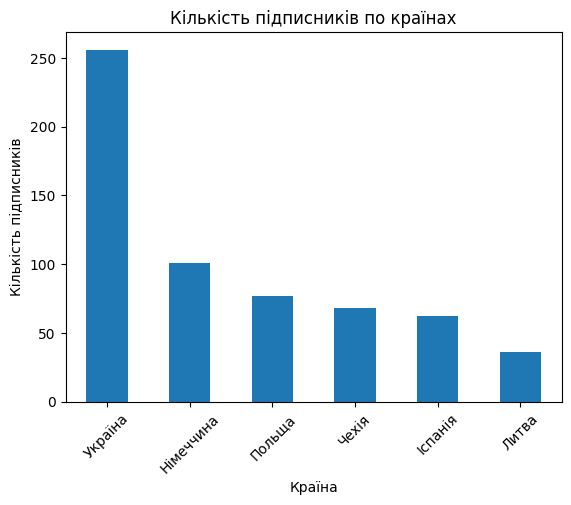

In [224]:
# Завдання 51:
subs['country'].value_counts().plot(kind='bar', rot=45)

plt.title('Кількість підписників по країнах')
plt.xlabel('Країна')
plt.ylabel('Кількість підписників')

plt.show()

**Завдання 52.** Побудуйте кругову діаграму (`pie`) розподілу підписників за тарифами.

> 💡 `value_counts().plot(kind="pie")`.

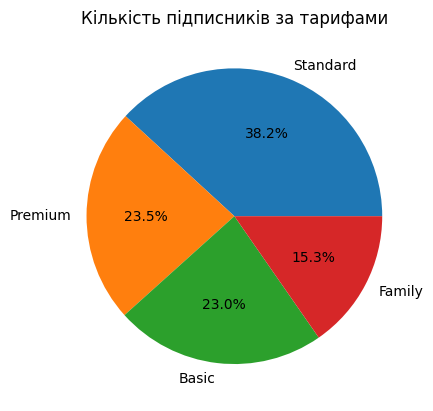

In [225]:
# Завдання 52:
subs['plan'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Кількість підписників за тарифами')
plt.ylabel('')
plt.show()

**Завдання 53.** Побудуйте гістограму розподілу віку підписників.

> 💡 `subs["age"].plot(kind="hist")`.

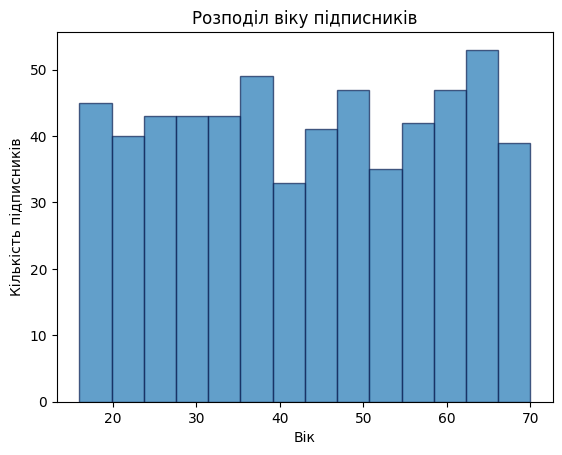

In [226]:
# Завдання 53:
subs['age'].plot(kind='hist', bins=14, edgecolor='#0e2154', alpha=0.7)

plt.title('Розподіл віку підписників')
plt.xlabel('Вік')
plt.ylabel('Кількість підписників')

plt.show()

**Завдання 54.** Побудуйте гістограму тривалості сеансів з 20 інтервалами (bins).

> 💡 Параметр `bins=20`.

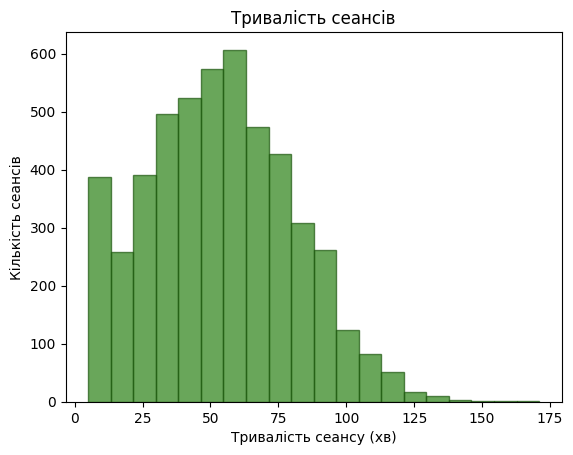

In [227]:
# Завдання 54:
sess['duration_min'].plot(kind='hist', bins=20, color='#2a8014', edgecolor='#1d570e', alpha=0.7)

plt.title('Тривалість сеансів')
plt.xlabel('Тривалість сеансу (хв)')
plt.ylabel('Кількість сеансів')

plt.show()

**Завдання 55.** Побудуйте лінійну діаграму кількості сеансів по місяцях. Спочатку згрупуйте за місяцем, потім `.plot()`.

> 💡 `sess.groupby("month").size().plot()`.

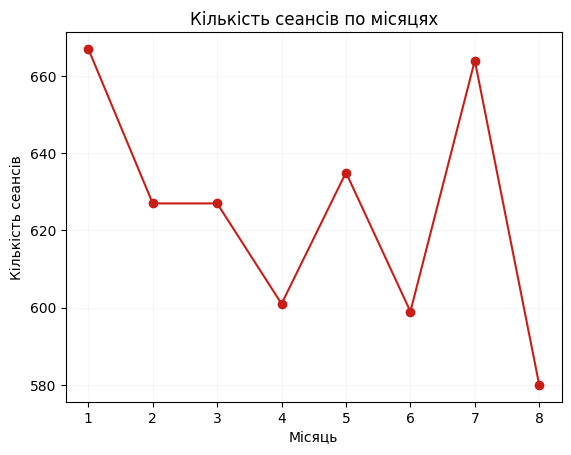

In [228]:
# Завдання 55:
sess.groupby('month').size().plot(kind='line', color='#c91e18', marker='o')

plt.title('Кількість сеансів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Кількість сеансів')
plt.grid(alpha=0.1)

plt.show()

**Завдання 56.** Побудуйте горизонтальну стовпчасту діаграму кількості сеансів по жанрах.

> 💡 `kind="barh"`.

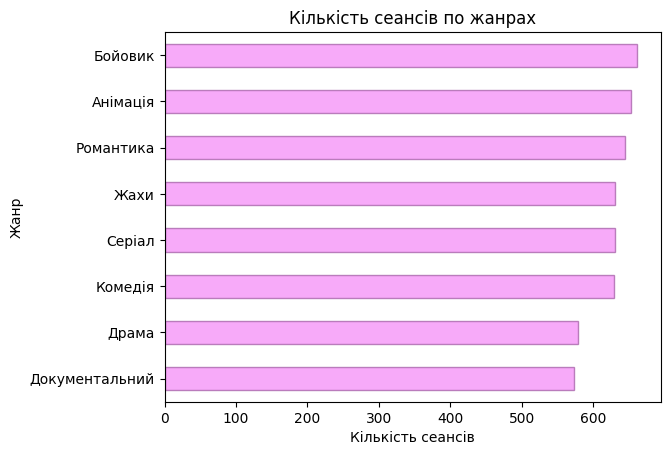

In [254]:
# Завдання 56:
sess['genre'].value_counts().sort_values().plot(kind='barh', color='#f486f7', edgecolor='#9f57a1', alpha=0.7)

plt.title('Кількість сеансів по жанрах')
plt.xlabel('Кількість сеансів')
plt.ylabel('Жанр')

plt.show()

**Завдання 57.** Побудуйте стовпчасту діаграму середньої оцінки (`rating`) по жанрах.

> 💡 `groupby("genre")["rating"].mean().plot(kind="bar")`.

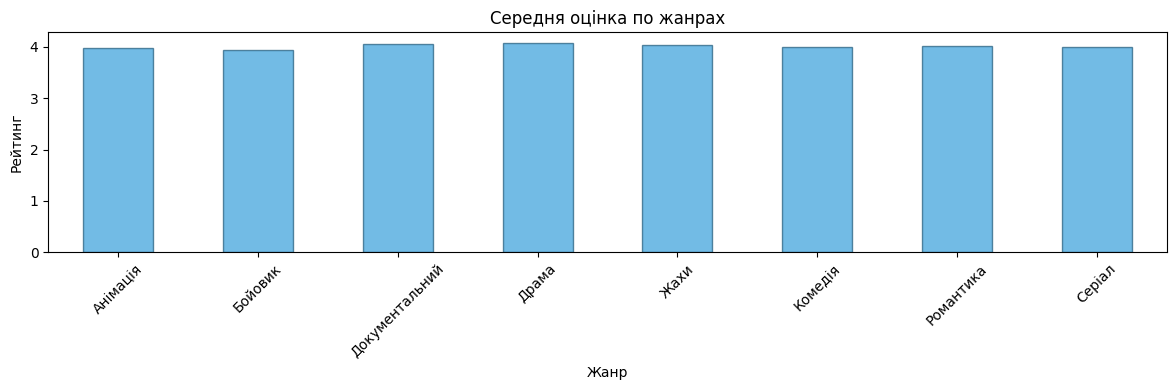

In [230]:
# Завдання 57:
plt.figure(figsize=(12, 4))
sess.groupby('genre')['rating'].mean().plot(kind='bar', color='#379fdb', edgecolor='#1f597a', alpha=0.7, rot=45)

plt.title('Середня оцінка по жанрах')
plt.xlabel('Жанр')
plt.ylabel('Рейтинг')

plt.tight_layout()
plt.show()

**Завдання 58.** Побудуйте scatter plot (точкову): по осі X — `duration_min`, по осі Y — `rating` (з таблиці `sess`).

> 💡 `sess.plot(kind="scatter", x="duration_min", y="rating")`.

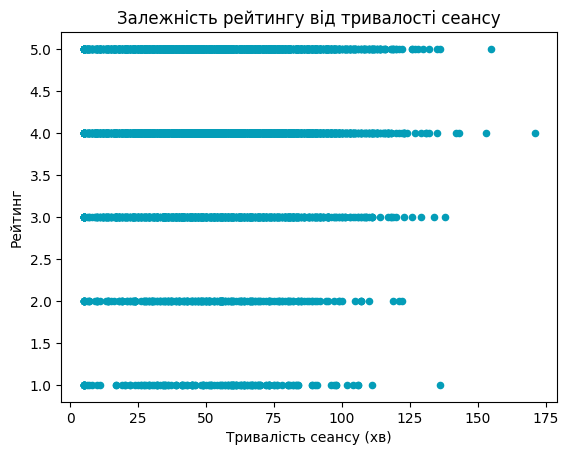

In [231]:
# Завдання 58:
sess.plot(kind='scatter', x='duration_min', y='rating', color='#049db8')

plt.title('Залежність рейтингу від тривалості сеансу')
plt.xlabel('Тривалість сеансу (хв)')
plt.ylabel('Рейтинг')

plt.show()

## Розділ 2.2. Основи matplotlib (завдання 59-66)

matplotlib дає більше контролю. Базовий синтаксис:

```python
plt.figure(figsize=(8, 5))   # розмір графіка
plt.bar(категорії, значення) # bar / line / scatter / hist
plt.title("Заголовок")
plt.xlabel("Назва X")
plt.ylabel("Назва Y")
plt.show()
```

Функції: `plt.bar()`, `plt.barh()`, `plt.plot()`, `plt.hist()`, `plt.scatter()`, `plt.pie()`.

**Завдання 59.** Створіть стовпчасту діаграму через `plt.bar()`. По осі X — країни, по осі Y — кількість підписників.

> 💡 Спочатку отримайте дані: `counts = subs["country"].value_counts()`. Потім: `plt.bar(counts.index, counts.values)`.

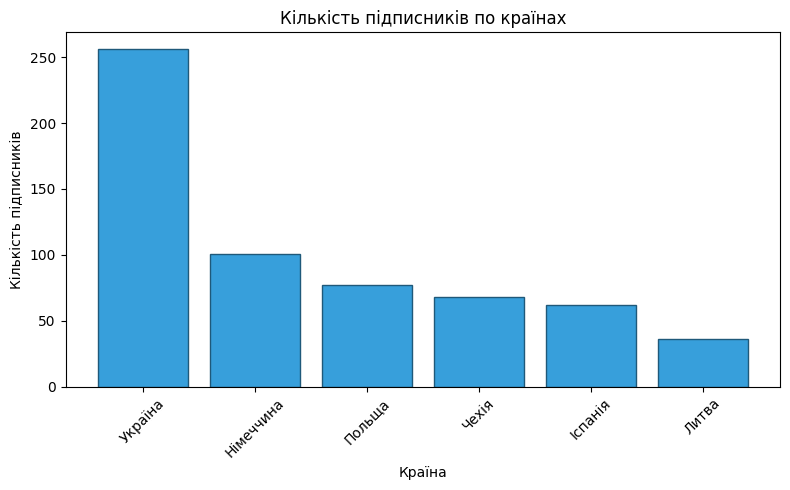

In [267]:
# Завдання 59:
counts = subs['country'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='#379fdb', edgecolor='#1f597a')

plt.title('Кількість підписників по країнах')
plt.xlabel('Країна')
plt.ylabel('Кількість підписників')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Завдання 60.** Створіть лінійну діаграму через `plt.plot()`: динаміка кількості сеансів по місяцях.

> 💡 `monthly = sess.groupby("month").size()` + `plt.plot(monthly.index, monthly.values)`.

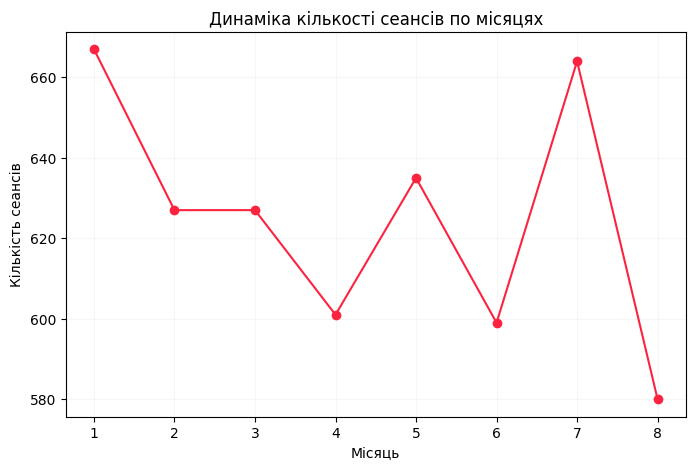

In [268]:
# Завдання 60:
monthly = sess.groupby('month').size()

plt.figure(figsize=(8, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='#fc2340')

plt.title('Динаміка кількості сеансів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Кількість сеансів')
plt.grid(alpha=0.1)

plt.show()


**Завдання 61.** Створіть гістограму віку підписників через `plt.hist()` з 15 інтервалами.

> 💡 `plt.hist(subs["age"], bins=15)`.

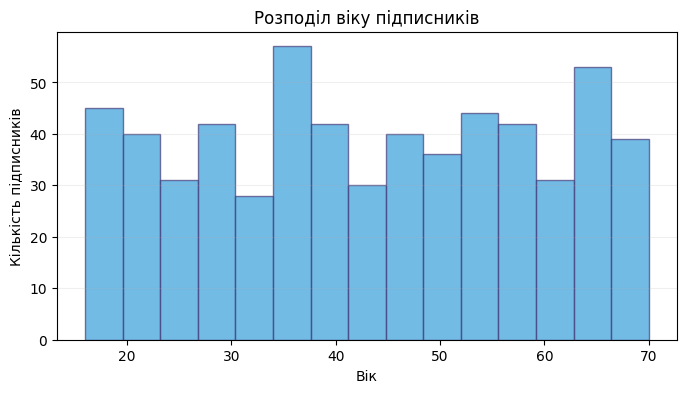

In [269]:
# Завдання 61:
plt.figure(figsize=(8, 4))
plt.hist(subs['age'], bins=15, color='#379fdb', edgecolor='#473c7a', alpha=0.7)

plt.title('Розподіл віку підписників')
plt.xlabel('Вік')
plt.ylabel('Кількість підписників')
plt.grid(axis='y', alpha=0.2)

plt.show()

**Завдання 62.** Створіть точкову діаграму через `plt.scatter()`: вік підписників по X, місячна плата по Y.

> 💡 `plt.scatter(subs["age"], subs["monthly_fee"])`.

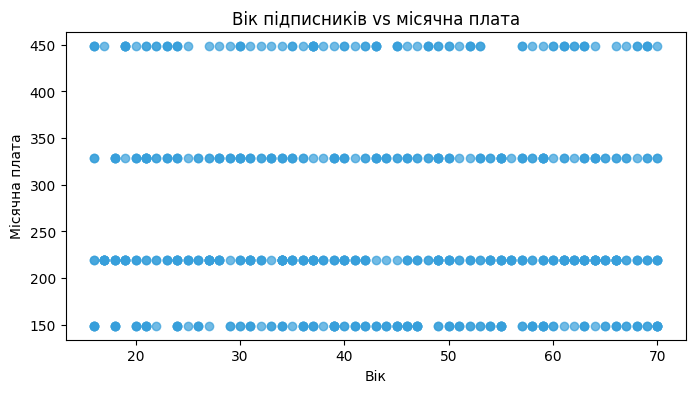

In [270]:
# Завдання 62:
plt.figure(figsize=(8, 4))
plt.scatter(subs['age'], subs['monthly_fee'], alpha=0.7, color='#379fdb')

plt.title('Вік підписників vs місячна плата')
plt.xlabel('Вік')
plt.ylabel('Місячна плата')

plt.show()

**Завдання 63.** Створіть кругову діаграму через `plt.pie()`: розподіл сеансів за пристроями.

> 💡 `counts = sess["device"].value_counts()` + `plt.pie(counts.values, labels=counts.index)`.

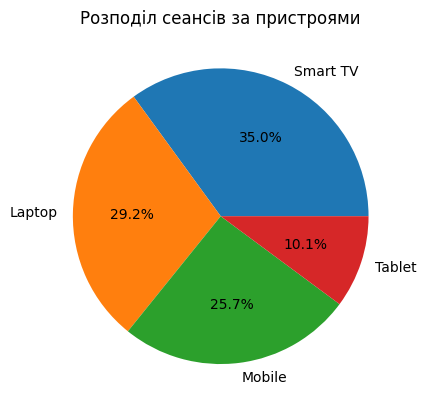

In [271]:
# Завдання 63:
counts = sess['device'].value_counts()

plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Розподіл сеансів за пристроями')

plt.show()

**Завдання 64.** Побудуйте графік з розміром 10x6 дюймів через `plt.figure(figsize=...)`. Можна побудувати будь-який — наприклад, кількість сеансів по жанрах.

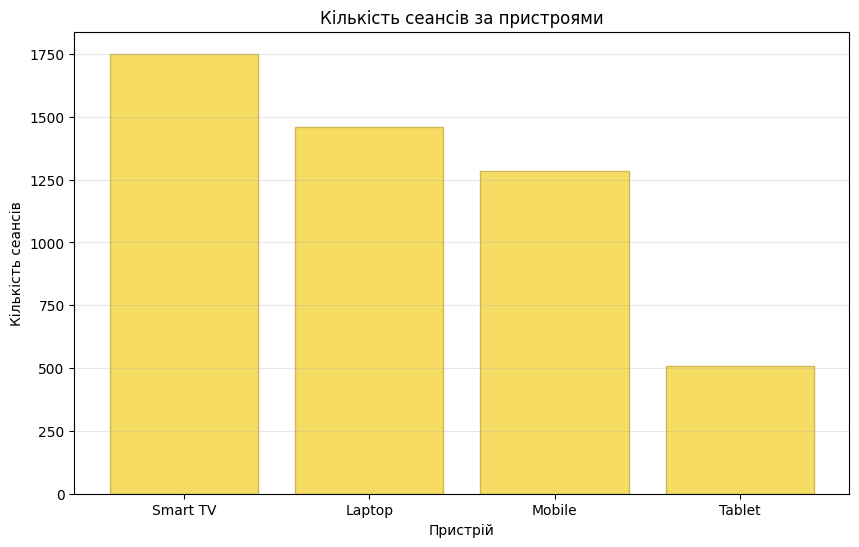

In [288]:
# Завдання 64:
plt.figure(figsize=(10, 6))
counts = sess['device'].value_counts()

plt.bar(counts.index, counts.values, color='#f7dc63', edgecolor='#cfb853')

plt.title('Кількість сеансів за пристроями')
plt.xlabel('Пристрій')
plt.ylabel('Кількість сеансів')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Завдання 65.** Побудуйте горизонтальну стовпчасту діаграму через `plt.barh()`: кількість сеансів по жанрах.

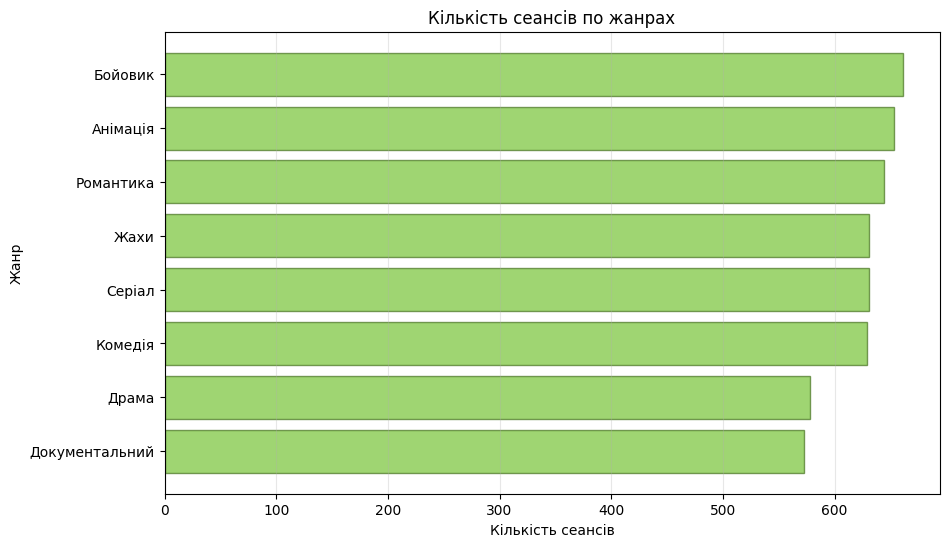

In [289]:
# Завдання 65:
plt.figure(figsize=(10, 6))
counts = sess['genre'].value_counts().sort_values()

plt.barh(counts.index, counts.values, color='#77c437', edgecolor='#467320', alpha=0.7)

plt.title('Кількість сеансів по жанрах')
plt.xlabel('Кількість сеансів')
plt.ylabel('Жанр')
plt.grid(axis='x', alpha=0.3)

plt.show()

**Завдання 66.** Побудуйте дві гістограми на одній фігурі (виклик `plt.hist` двічі підряд перед `plt.show()`): вік активних підписників та вік неактивних. Використайте параметр `alpha=0.5` для прозорості.

> 💡 `plt.hist(...активні..., alpha=0.5)` потім `plt.hist(...неактивні..., alpha=0.5)` потім `plt.show()`.

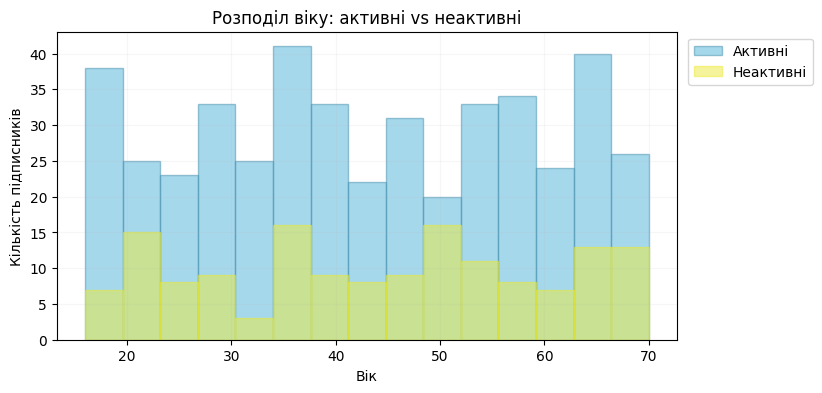

In [304]:
# Завдання 66:
plt.figure(figsize=(8, 4))

plt.hist(subs[subs['is_active'] == 'Так']['age'], bins=15, color='#4fb2db', edgecolor='#448ead', alpha=0.5, label='Активні')
plt.hist(subs[subs['is_active'] == 'Ні']['age'], bins=15, color='#edea3b', edgecolor='#edea2b', alpha=0.5, label='Неактивні')

plt.title('Розподіл віку: активні vs неактивні')
plt.xlabel('Вік')
plt.ylabel('Кількість підписників')
plt.grid(alpha=0.1)

plt.legend(bbox_to_anchor=(1.23, 1), loc='upper right')

plt.show()

## Розділ 2.3. Налаштування графіків (завдання 67-74)

Тепер додаємо красу і інформативність:
- `plt.title("...")` — заголовок
- `plt.xlabel("...")`, `plt.ylabel("...")` — підписи осей
- `color="..."` — колір (`"red"`, `"#02C39A"`, `"teal"` тощо)
- `plt.xticks(rotation=45)` — повернути підписи по X
- `plt.grid(True)` — додати сітку
- `plt.figure(figsize=(w, h))` — розмір

**Завдання 67.** Побудуйте стовпчасту діаграму кількості підписників по країнах. Додайте заголовок "Кількість підписників по країнах", підпис осі X "Країна" та осі Y "Кількість".

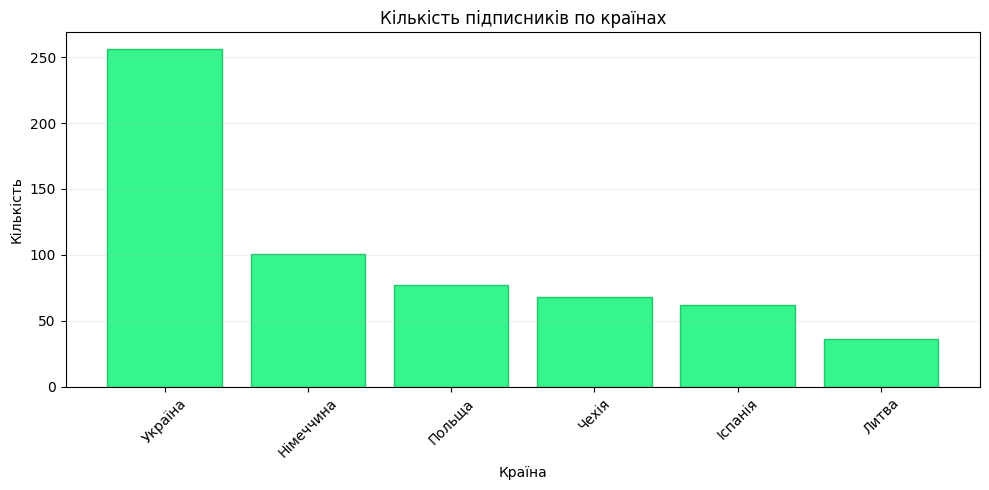

In [312]:
# Завдання 67:
counts = subs['country'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values, color='#36f58c', edgecolor='#22c76d')

plt.title('Кількість підписників по країнах')
plt.xlabel('Країна')
plt.ylabel('Кількість')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

**Завдання 68.** Побудуйте графік середньої тривалості сеансу по жанрах. Усі стовпці зробіть КОЛЬОРОМ `teal`.

> 💡 Параметр `color="teal"` всередині `plt.bar()` або `.plot(kind="bar")`.

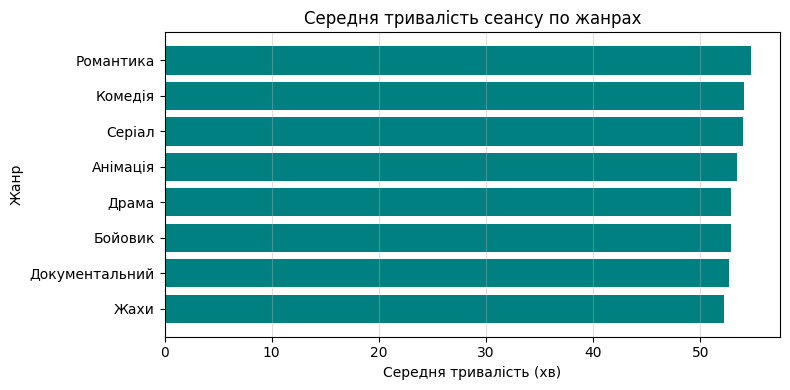

In [319]:
# Завдання 68:
avg_duration = sess.groupby('genre')['duration_min'].mean().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(avg_duration.index, avg_duration.values, color='teal')

plt.title('Середня тривалість сеансу по жанрах')
plt.xlabel('Середня тривалість (хв)')
plt.ylabel('Жанр')
plt.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

**Завдання 69.** Побудуйте гістограму віку з 20 інтервалами. Колір — `"#02C39A"` (бірюзовий), додайте заголовок.

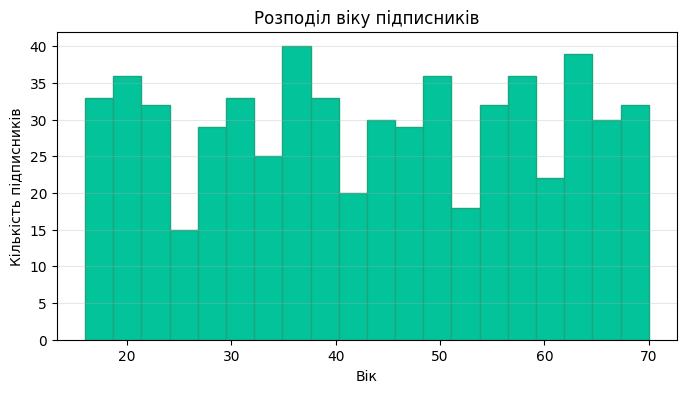

In [330]:
# Завдання 69:
plt.figure(figsize=(8, 4))
plt.hist(subs['age'], bins=20, color='#02C39A', edgecolor='#1ca67f')

plt.title('Розподіл віку підписників')
plt.xlabel('Вік')
plt.ylabel('Кількість підписників')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Завдання 70.** Побудуйте діаграму кількості сеансів по місяцях. Підписи на осі X поверніть на 45 градусів.

> 💡 `plt.xticks(rotation=45)`.

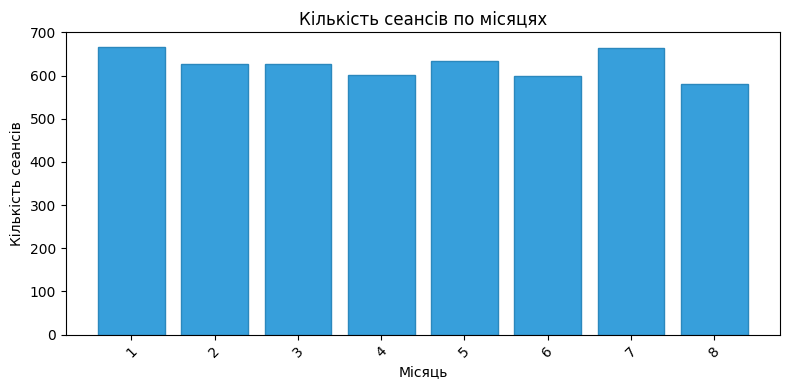

In [332]:
# Завдання 70:
counts = sess.groupby('month').size()

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values, color='#379fdb', edgecolor='#2b88bd')

plt.title('Кількість сеансів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Кількість сеансів')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Завдання 71.** Побудуйте стовпчасту діаграму середнього `monthly_fee` по тарифах. Розмір фігури 8x5. Додайте сітку.

> 💡 `plt.grid(True)`. Сітка для bar-діаграм виглядає краще тільки по осі Y: `plt.grid(axis="y")`.

In [244]:
# Завдання 71:


**Завдання 72.** Побудуйте лінійну діаграму кількості сеансів по місяцях. Тип лінії: пунктир, колір червоний, маркери у вигляді крапок.

> 💡 У `plt.plot()` параметри: `linestyle="--"`, `color="red"`, `marker="o"`. Або скорочено: `"r--o"`.

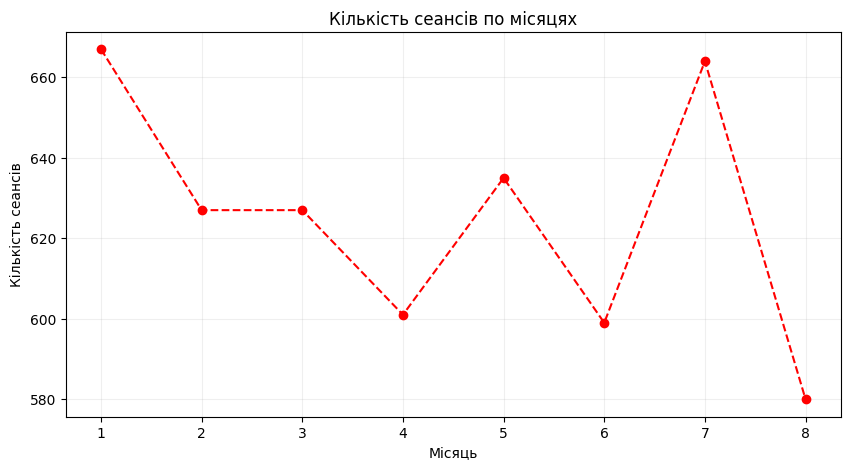

In [334]:
# Завдання 72:
counts = sess.groupby('month').size()

plt.figure(figsize=(10, 5))
plt.plot(counts.index, counts.values, linestyle='--', color='red', marker='o')

plt.title('Кількість сеансів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Кількість сеансів')
plt.grid(alpha=0.2)

plt.show()

**Завдання 73.** Побудуйте scatter plot: вік (X) vs місячна плата (Y). Колір точок зробіть напівпрозорим (`alpha=0.3`).

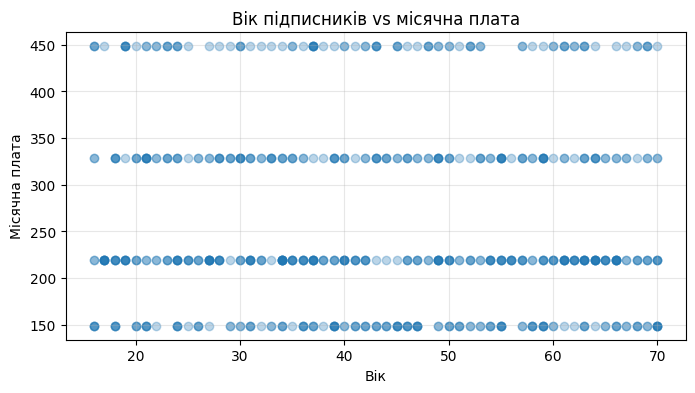

In [337]:
# Завдання 73:
plt.figure(figsize=(8, 4))
plt.scatter(subs['age'], subs['monthly_fee'], alpha=0.3)

plt.title('Вік підписників vs місячна плата')
plt.xlabel('Вік')
plt.ylabel('Місячна плата')
plt.grid(alpha=0.3)

plt.show()

**Завдання 74.** Побудуйте кругову діаграму розподілу підписників за тарифами. Покажіть відсотки на кожному секторі.

> 💡 Параметр `autopct="%1.1f%%"` у `plt.pie()`.

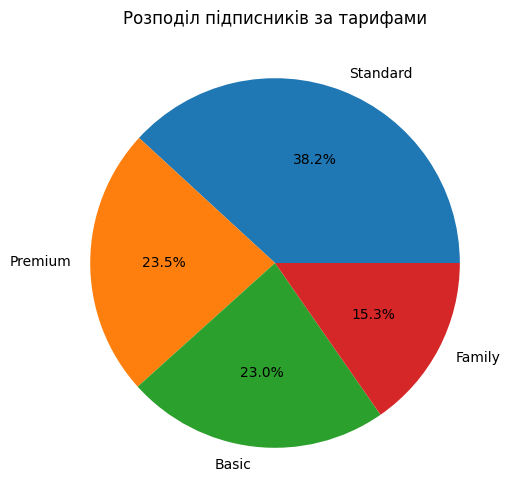

In [339]:
# Завдання 74:
counts = subs['plan'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Розподіл підписників за тарифами')

plt.show()

## Розділ 2.4. Легенди, кілька серій, subplots (завдання 75-80)

Кілька серій на одному графіку:
- Кожна серія має параметр `label="..."`
- Викликаємо `plt.legend()` — показуємо легенду

Кілька графіків поруч (subplots):
```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(...)
axes[0].set_title("Перший")
axes[1].plot(...)
axes[1].set_title("Другий")
plt.show()
```

**Завдання 75.** На одному графіку побудуйте дві лінії: кількість сеансів по місяцях для Smart TV та для Mobile. Додайте легенду з підписами.

> 💡 Двічі викличте `plt.plot(...)` з різними даними, кожен з параметром `label="..."`. Потім `plt.legend()`.

In [248]:
# Завдання 75:


**Завдання 76.** На одному графіку побудуйте дві гістограми віку: окремо для чоловіків і жінок (з прозорістю `alpha=0.5` та різними кольорами). Додайте легенду.

In [249]:
# Завдання 76:


**Завдання 77.** Побудуйте дві стовпчасті діаграми поруч через `subplots(1, 2)`:
- зліва: кількість підписників по країнах
- справа: кількість підписників по тарифах

Кожній додайте заголовок.

In [250]:
# Завдання 77:


**Завдання 78.** Побудуйте 2x2 сітку графіків (`subplots(2, 2)`):
- (0,0): гістограма віку
- (0,1): кількість сеансів по жанрах (bar)
- (1,0): розподіл пристроїв (pie)
- (1,1): середня тривалість по жанрах (barh)

Кожному додайте заголовок. Розмір фігури — 12x10.

> 💡 `fig, axes = plt.subplots(2, 2, figsize=(12, 10))`. Доступ: `axes[0, 0]`, `axes[0, 1]`, `axes[1, 0]`, `axes[1, 1]`.

In [251]:
# Завдання 78:


**Завдання 79.** Побудуйте графік середньої оцінки по жанрах. Стовпці пофарбуйте у РІЗНІ кольори (передайте список кольорів у параметр `color`).

> 💡 `color=["red","blue","green","orange","purple","teal","pink","gray"]` — стільки кольорів, скільки жанрів.

In [252]:
# Завдання 79:


**Завдання 80.** Зробіть фінальний дашборд: 2x1 сітка (один графік над іншим), розмір 10x10.
- зверху: лінійна діаграма кількості сеансів по місяцях, з заголовком "Динаміка переглядів 2024"
- знизу: горизонтальна стовпчаста діаграма топ-10 жанрів за кількістю сеансів, з заголовком "Топ жанрів"

Після всього — `plt.tight_layout()` (виправляє накладання).

> 💡 `fig, axes = plt.subplots(2, 1, figsize=(10, 10))` + наприкінці `plt.tight_layout()`.

In [253]:
# Завдання 80:


---

# 🎉 Готово!

Якщо ви виконали всі 80 завдань — вітаємо! Ви відпрацювали:

**Pandas (50 завдань):**
- ✅ `loc` та `iloc` — потужна вибірка за позицією та умовою
- ✅ Складніший `groupby` з `.agg()`, `.transform()`, групування за кількома стовпцями
- ✅ `pivot_table` — зведені таблиці у стилі Excel
- ✅ Робота з датами (`.dt.month`, `.dt.day_name`, різниця дат)
- ✅ Об'єднання таблиць через `merge`

**Matplotlib (30 завдань):**
- ✅ Швидкі графіки через pandas `.plot()`
- ✅ Базові функції matplotlib: `bar`, `plot`, `hist`, `scatter`, `pie`
- ✅ Налаштування: заголовки, осі, кольори, сітка
- ✅ Легенди та кілька серій на одному графіку
- ✅ Subplots — кілька графіків поруч

### Порада
Найкращий спосіб запам'ятати — повернутись через тиждень і спробувати найскладніші завдання знову, не підглядаючи. **Так тримати! 🐼📊**
